# Modelo VGG


### Impotacion y preprocesado de datos

In [ ]:
from importacion_preprocesado import descarga_y_carga_de_datos, preprocesamiento


tamany_img = (128,128) # tamaño reducido para colab, porque si no supera la ram
X, y = descarga_y_carga_de_datos(target_size=tamany_img)

X_train, X_val, X_test, y_train, y_val, y_test = preprocesamiento(X, y)

Dataset ya existe, solo se van a cargar las imágenes.


### Modelo

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator



vgg = VGG16(
  weights='imagenet',  # Pre-entrenado en ImageNet
  input_shape=(128,128,3),
  include_top=False  # Sin capa de salida (la agregaremos nosotros)
)

for layers in vgg.layers:
    layers.trainable = False


# restnet.summary()



In [ ]:
# CREAR modelo personalizado
model = Sequential()

# Agregar capas personalizadas para nuestro problema
model.add(vgg)


model.add(GlobalAveragePooling2D())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(4, activation='softmax'))

# Compilar
optimizer = Adam(learning_rate=0.0001)
model.compile(
  optimizer=optimizer,
  loss='categorical_crossentropy',
  metrics=['accuracy']
)



In [ ]:
hist = model.fit(X_train, y_train, validation_data= (X_val, y_val), epochs= 70)

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.3491 - loss: 1.3623 - val_accuracy: 0.5273 - val_loss: 1.1760
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 68s 854ms/step - accuracy: 0.4500 - loss: 1.1853 - val_accuracy: 0.5320 - val_loss: 1.0481
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 72s 904ms/step - accuracy: 0.5172 - loss: 1.0780 - val_accuracy: 0.6825 - val_loss: 0.9499
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 66s 828ms/step - accuracy: 0.5698 - loss: 0.9869 - val_accuracy: 0.6979 - val_loss: 0.8643
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 66s 830ms/step - accuracy: 0.6232 - loss: 0.9104 - val_accuracy: 0.7405 - val_loss: 0.7960
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 63s 789ms/step - accuracy: 0.6501 - loss: 0.8507 - val_accuracy: 0.7476 - val_loss: 0.7387
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 63s 791ms/step - accuracy: 0.6805 - loss: 0.7915 - val_accuracy: 0.7382 - val_loss: 0.7014
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 69s 863ms/step - accuracy: 0.7026 - loss: 0.7510 - val_accurac

### Resultados

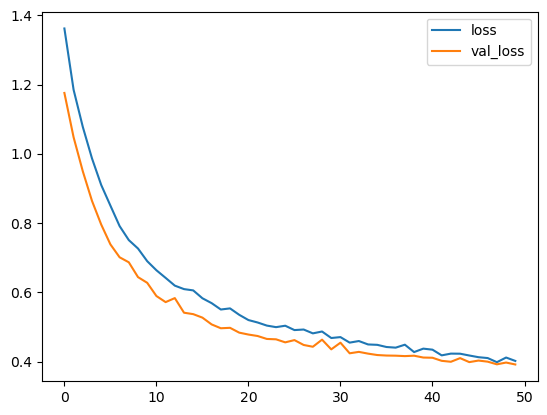

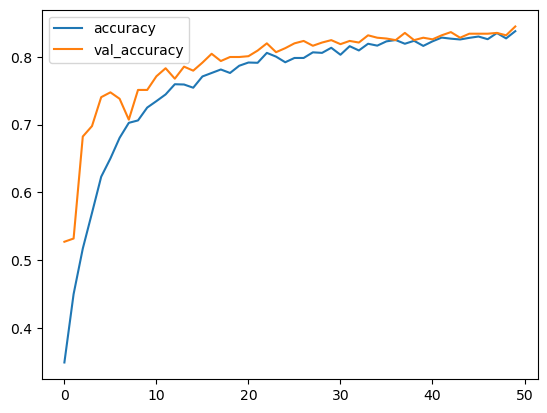

In [ ]:
import matplotlib.pyplot as plt
# número de épocas para el zoom
zoom_epochs = 20

loss = hist.history['loss']
val_loss = hist.history['val_loss']
epochs = range(1, len(loss) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Visualizacion evolucion loss durante el entrenamiento
ax[0].plot( loss, label='Train loss')
ax[0].plot( val_loss, label='Val loss')
ax[0].set_title('Training evolution')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

# Zoom últimas épocas
ax[1].plot(epochs[-zoom_epochs:], loss[-zoom_epochs:], label='Train loss')
ax[1].plot(epochs[-zoom_epochs:], val_loss[-zoom_epochs:], label='Val loss')
ax[1].set_title(f'Zoom últimas {zoom_epochs} epocas')
ax[1].set_xlabel('Epoch')
ax[1].legend()

plt.tight_layout()
plt.show()

# Visualizacion de accuracy durante el entrenamiento
plt.plot(hist.history["accuracy"], label= "accuracy")
plt.plot(hist.history["val_accuracy"], label ="val_accuracy")
plt.title("Accuracy durante el entrenamiento")
plt.legend()
plt.show()

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

datasets = {
    "Train": (X_train, y_train),
    "Val": (X_val, y_val),
    "Test": (X_test, y_test)
}

def evaluate(model, X, y):
    #Convertir a enteros
    y_true = np.argmax(y, axis=1)

    y_pred_probs = model.predict(X)
    y_pred = np.argmax(y_pred_probs, axis=1)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")
    return acc, f1


def crear_df_metricas(model, datasets):
    results = {}
    for split_name, (X, y) in datasets.items():
        acc, f1 = evaluate(model, X, y)
        results[split_name] = [acc, f1]
    
    df = pd.DataFrame(results, index=["Accuracy", "F1"])
    return df

NameError: name 'X_train' is not defined

In [33]:
df = crear_df_metricas(model, datasets)
print(df.round(3))

80/80 ━━━━━━━━━━━━━━━━━━━━ 47s 590ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 16s 573ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 567ms/step
          Train    Val   Test
Accuracy  0.844  0.845  0.842
F1        0.844  0.844  0.841


In [10]:
def plot_barra(metrica, titulo, color):

    plt.figure(figsize=(6,4))
    bars = plt.bar(metrica.index, metrica.values, color=color)
    plt.bar_label(bars)
    plt.title(f"{titulo}: Train vs Validation vs Test")
    plt.ylabel(titulo)
    plt.ylim(0,1)
    plt.grid(axis='y', linestyle='--')
    plt.show()


def plots_metricas(df):
    #Extraemos la fila
    accuracy = df.loc["Accuracy"]
    f1 = df.loc["F1"]

    #Grafico de Accuracy
    plot_barra(accuracy, titulo = "Accuracy", color="blue")

    #Grafico de 
    plot_barra(f1, titulo ="F1", color = "red")

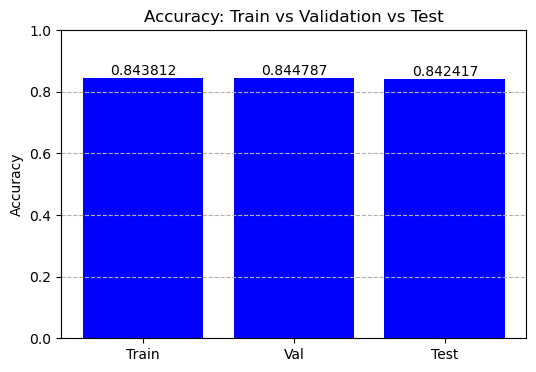

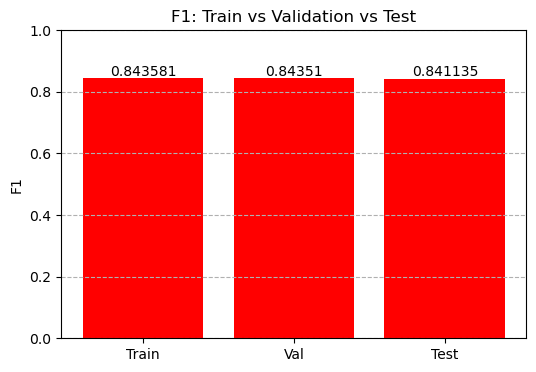

In [34]:
plots_metricas(df)

27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 570ms/step


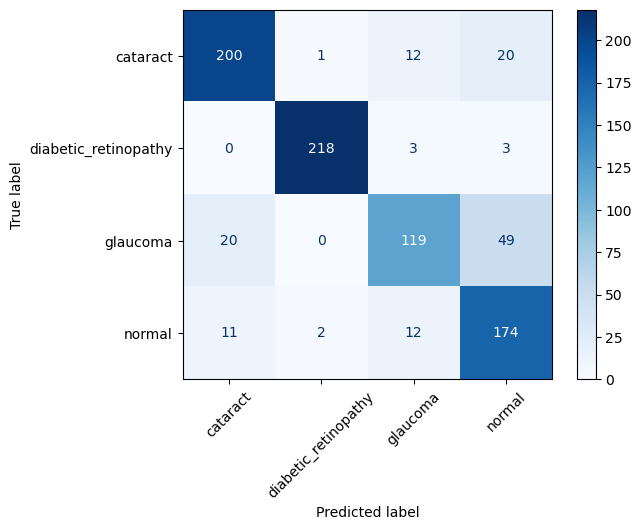

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm,  
                    display_labels= ["cataract", "diabetic_retinopathy", "glaucoma", "normal"]
                    ).plot(cmap="Blues", xticks_rotation= 45.0)

In [2]:
from sklearn.metrics import precision_recall_fscore_support

def per_class_table(model, datasets):
    # class_names: lista con nombres de las clases en el orden de los índices (opcional)
    class_names = ["cataract", "diabetic_retinopathy", "glaucoma", "normal"]  

    splits = list(datasets.keys())
    # identificamos número de clases desde los datos si no dan nombres
    sample_X, sample_y = next(iter(datasets.values()))
    n_classes = np.argmax(sample_y, axis=1).max() + 1

    # DataFrame con index = clases y columnas por split/metric
    cols = []
    for s in splits:
        cols += [f"{s}_Accuracy", f"{s}_F1"]
    df = pd.DataFrame(index=class_names, columns=cols, dtype=float)

    for split in splits:
        X, y = datasets[split]
        y_true = np.argmax(y, axis=1)
        y_pred = np.argmax(model.predict(X), axis=1)

        # precision, recall, f1 por clase
        precision, recall, f1, support = precision_recall_fscore_support(
            y_true, y_pred, labels=np.arange(n_classes), zero_division=0
        )
        # Aquí definimos "Accuracy" por clase como recall (TP / nº verdaderos de la clase)
        for i, cls in enumerate(class_names):
            df.loc[cls, f"{split}_Accuracy"] = recall[i]
            df.loc[cls, f"{split}_F1"] = f1[i]

    return df

In [36]:
df_per_class = per_class_table(model, datasets)
print(df_per_class.round(3))

80/80 ━━━━━━━━━━━━━━━━━━━━ 47s 585ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 16s 595ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 16s 589ms/step
                      Train_Accuracy  Train_F1  Val_Accuracy  Val_F1  \
cataract                       0.821     0.857         0.842   0.851   
diabetic_retinopathy           0.994     0.989         0.987   0.981   
glaucoma                       0.696     0.741         0.677   0.727   
normal                         0.859     0.787         0.847   0.795   

                      Test_Accuracy  Test_F1  
cataract                      0.858    0.862  
diabetic_retinopathy          0.973    0.980  
glaucoma                      0.633    0.713  
normal                        0.874    0.782  


Resultado resnet:
          Train    Val   Test
Accuracy  0.484  0.468  0.469
F1        0.445  0.431  0.439

resultDO VGG:
          Train    Val   Test
Accuracy  0.811  0.808  0.807
F1        0.811  0.809  0.807
